## Imputation of time-series

Some of the code was found here for visualisation: https://cienciadedatos.net/documentos/py46-forecasting-time-series-missing-values

In [1]:
!nvidia-smi

Tue Apr 21 12:04:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:01:00.0 Off |                  N/A |
|  0%   24C    P8              2W /  600W |    2181MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
import math
import torch
import torch.nn as nn

import argparse
import torch
import datetime
import json
import yaml
import os

import sys

sys.path.append(".")
sys.path.append("./models")

from models.unet_main_model import Unet_WaterQual
from utils import *

import matplotlib.pyplot as plt


In [3]:
color = '\033[1m\033[38;5;208m' 
print(f"{color}Version numpy: {np.__version__}")
print(f"{color}Version pytorch: {torch.__version__}")

Version numpy: 2.4.4
Version pytorch: 2.8.0+cu128


### Load Data

In [4]:
from dataset_synthetic import get_dataloader
gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, valid_loader, test_loader = get_dataloader(device=gpu, batch_size=8)

Loaded SAGD training data with shape:  (100000, 25)
Training dataset len:  4128
Loaded SAGD training data with shape:  (100000, 25)
Valid dataset len:  15
Loaded SAGD training data with shape:  (100000, 25)
Test dataset len:  21


In [5]:
data_dim = 25

## Model Definition and Training

In [6]:
# Load the config

# My own config for cigeo
path = "./config/unet_config.yaml"

with open(path, "r") as f:
    config = yaml.safe_load(f)

# The only thing I overwrite, so I can change epochs for my tests
# EPOCHS
config["train"]["epochs"] = 100

current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S") 
foldername = (
    "./save/validationindex" + "_" + current_time
)

os.makedirs(foldername, exist_ok=True)
with open(foldername + "config.json", "w") as f:
    json.dump(config, f, indent=4)


In [7]:
do_train = True

device = torch.device("cuda")
model = Unet_WaterQual(config, "cuda:0", target_dim=data_dim).to("cuda:0")

if do_train:
# define and train mode. keep an history for monitoring
    history = {}
    # Run on GPU

    # It returns history, which we don't need really
    _ = train(
        model,
        config["train"],
        train_loader,
        valid_loader=valid_loader,
        foldername=foldername,
        lr=1e-5,
        history=history)

100%|██████████| 2/2 [00:00<00:00, 608.93it/s, valid_avg_epoch_loss=0.00862, epoch=19]



 best loss is updated to  0.008616264909505844 at 19


100%|██████████| 2/2 [00:00<00:00, 865.88it/s, valid_avg_epoch_loss=0.0246, epoch=99]


In [8]:
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))


model size: 0.644MB


## Tests

In [9]:
#train_loader, valid_loader, test_loader, scaler, mean_scaler = get_dataloader(device=gpu, batch_size=8)

In [10]:
for batch in test_loader:
    observed_mask_forecast = batch['observed_mask']
    # set later half to 0
    print(observed_mask_forecast.shape)
    observed_mask_forecast[:, 25:] = 0
    


    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_forecast

    observed_mask_forecast = observed_mask_forecast.to(model.device).float()
    observed_data = observed_data.to(model.device).float()
    
    with torch.no_grad():
        generated = model.impute(observed_data, observed_mask_forecast, n_samples=1, timestamps=batch['timepoints'])
        break

torch.Size([8, 72, 25])


In [11]:
generated_test = generated.cpu().permute([0, 1, 3, 2]).numpy()[0].squeeze()
observations = observed_data[0].squeeze().cpu().numpy()
mask = observed_mask_forecast[0].squeeze().cpu().numpy()
timestamps = batch['timepoints'][0].squeeze().numpy()

In [12]:
generated_test.shape, observations.shape, mask.shape, timestamps.shape

((72, 25), (72, 25), (72, 25), (72,))

### Single generation test

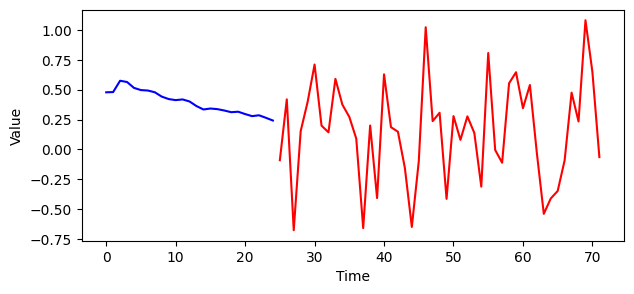

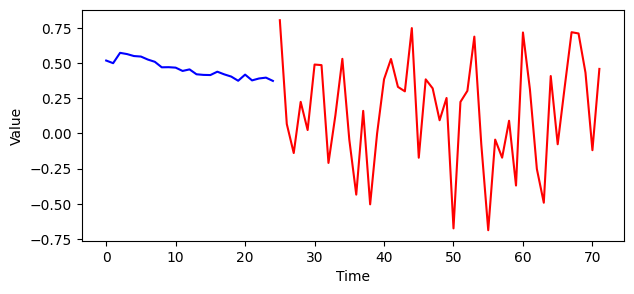

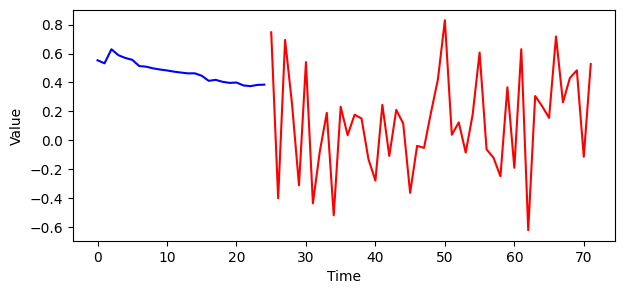

In [13]:
def find_gaps(serie_training_mask):
    """
    Return the indices of the gaps in values based on the training mask.
    """

    padded_mask = np.pad(np.logical_not(serie_training_mask).astype(int), (1,1), mode='constant', constant_values=0)

    gaps_start = np.where(np.diff(padded_mask) == 1)[0]
    gaps_end = np.where(np.diff(padded_mask) == -1)[0]

    gaps = np.array(list(zip(gaps_start, gaps_end)))

    return gaps

# Print gap filling

for i in range(3):
    fig, ax = plt.subplots(figsize=(7, 3))

    gen_squeezed = generated_test.squeeze()
    mask_squeezed = mask.squeeze()


    gaps = find_gaps(1 - mask_squeezed[:, i])
    for gap in gaps:
        if gap[1] <= len(gen_squeezed[:, i]) and gap[0] >= 0:
            ax.plot(
                np.linspace(gap[0], gap[1]-1, num=gap[1]-gap[0]),
                gen_squeezed[gap[0]:gap[1], i],
                color = 'blue',
                label = 'observations'
                )

    gaps = find_gaps(mask_squeezed[:, i])

    for gap in gaps:
        if gap[1] <= len(gen_squeezed[:, i]) and gap[0] >= 0:
            ax.plot(
                np.linspace(gap[0], gap[1]-1, num=gap[1]-gap[0]),
                gen_squeezed[gap[0]:gap[1], i],
                color = 'red',
                label = 'predictions'
                )
        
    #plt.title(test_station_name + " " +parameter_names[i])
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.plot()

### Evaluate forecasting

In [14]:
import numpy as np
from collections import defaultdict

horizons = [6, 12, 18]
n_trials = 5

results = {h: defaultdict(list) for h in horizons}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for h in horizons:
        out = evaluate_forecasting(
            model,
            test_loader,
            prediction_horizon=h,
            nsample=100,
            foldername=foldername
        )
        
        for key, value in out.items():
            results[h][key].append(value)

# Compute mean & std
print("\n=== Forecasting Results ===")
for h in horizons:
    print(f"\nHorizon: {h}")
    
    for metric in results[h]:
        values = np.array(results[h][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

Trial 1/5


100%|██████████| 3/3 [00:15<00:00,  5.25s/it, rmse_total=0.251, mae_total=0.208, smape_total=88.7, batch_no=3]


Trial 2/5


100%|██████████| 3/3 [00:15<00:00,  5.30s/it, rmse_total=0.252, mae_total=0.209, smape_total=89.9, batch_no=3]


Trial 3/5


...

Trial 4/5


100%|██████████| 3/3 [00:15<00:00,  5.29s/it, rmse_total=0.251, mae_total=0.208, smape_total=88.9, batch_no=3]


Trial 5/5


100%|██████████| 3/3 [00:15<00:00,  5.27s/it, rmse_total=0.25, mae_total=0.207, smape_total=87.7, batch_no=3] 



=== Forecasting Results ===

Horizon: 6
rmse: 0.2404 ± 0.0011
mae: 0.2013 ± 0.0013
smape: 85.5644 ± 0.7897
CRPS: 0.4319 ± 0.0020
CRPS_sum: 0.0357 ± 0.0002

Horizon: 12
rmse: 0.2484 ± 0.0008
mae: 0.2071 ± 0.0006
smape: 88.3506 ± 0.4370
CRPS: 0.4413 ± 0.0010
CRPS_sum: 0.0776 ± 0.0002

Horizon: 18
rmse: 0.2509 ± 0.0007
mae: 0.2080 ± 0.0007
smape: 88.8613 ± 0.7188
CRPS: 0.4442 ± 0.0009
CRPS_sum: 0.1208 ± 0.0004


In [15]:
import numpy as np
from collections import defaultdict

ratios = [0.25, 0.50, 0.75, 0.90]
n_trials = 5

results = {r: defaultdict(list) for r in ratios}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for seed, r in enumerate(ratios):
        out = evaluate_imputation(
            model,
            test_loader,
            ratio_missing=r,
            nsample=100,
            seed=seed,
            foldername=foldername
        )
        
        for key, value in out.items():
            results[r][key].append(value)

# Compute mean & std
print("\n=== Imputation Results ===")
for r in ratios:
    print(f"\nMissing Ratio: {r}")
    
    for metric in results[r]:
        values = np.array(results[r][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

Trial 1/5


100%|██████████| 3/3 [00:15<00:00,  5.25s/it, rmse_total=0.246, mae_total=0.205, smape_total=86.6, batch_no=3]


Trial 2/5


100%|██████████| 3/3 [00:15<00:00,  5.27s/it, rmse_total=0.246, mae_total=0.205, smape_total=86.3, batch_no=3]


Trial 3/5


...

Trial 4/5


100%|██████████| 3/3 [00:15<00:00,  5.27s/it, rmse_total=0.246, mae_total=0.205, smape_total=86.8, batch_no=3]


Trial 5/5


100%|██████████| 3/3 [00:15<00:00,  5.28s/it, rmse_total=0.247, mae_total=0.205, smape_total=86.8, batch_no=3]



=== Imputation Results ===

Missing Ratio: 0.25
rmse: 0.1629 ± 0.0004
mae: 0.1372 ± 0.0004
smape: 52.4132 ± 0.2071
CRPS: 0.2956 ± 0.0004
CRPS_sum: 0.0821 ± 0.0002

Missing Ratio: 0.5
rmse: 0.2082 ± 0.0003
mae: 0.1743 ± 0.0003
smape: 70.2633 ± 0.3969
CRPS: 0.3704 ± 0.0004
CRPS_sum: 0.2144 ± 0.0003

Missing Ratio: 0.75
rmse: 0.2342 ± 0.0001
mae: 0.1950 ± 0.0002
smape: 81.2690 ± 0.0595
CRPS: 0.4147 ± 0.0004
CRPS_sum: 0.3654 ± 0.0004

Missing Ratio: 0.9
rmse: 0.2461 ± 0.0003
mae: 0.2048 ± 0.0002
smape: 86.5986 ± 0.1939
CRPS: 0.4352 ± 0.0003
CRPS_sum: 0.4653 ± 0.0005


In [16]:
rng = np.random.RandomState(1)

# generate one batch
for batch in test_loader:
    observed_mask = batch['observed_mask']
    # set later half to 0
    #print(observed_mask_forecast.shape)
    real_data = batch['observed_data']

    observed_mask_forecast = observed_mask.clone()
    observed_mask_forecast[:, 18:] = 0

    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_forecast

    observed_mask_forecast = observed_mask_forecast.to(model.device).float()
    observed_data = observed_data.to(model.device).float()
    with torch.no_grad():
        generated = model.impute(observed_data, observed_mask_forecast, n_samples=100, timestamps=batch['timepoints'])
        break

In [17]:
generated_test = generated.permute([0, 1, 3, 2]).cpu()
X = np.arange(generated_test.shape[0]).reshape(-1, 1)

all_target_np = real_data
all_evalpoint_np = observed_mask.cpu() - observed_mask_forecast.cpu() #observed_mask_forecast.cpu() # with later points se tto 0
all_observed_np = observed_mask.cpu() # all points
all_given_np = observed_mask_forecast.cpu() # observations

K = generated_test.shape[-1] #feature
L = generated_test.shape[-2] #time length

In [18]:
def get_quantile(samples,q,dim=1):
    return torch.quantile(samples,q,axis=dim)

qlist =[0.05,0.25,0.5,0.75,0.95]
quantiles_imp= []
for q in qlist:
    quantiles_imp.append(get_quantile(generated_test, q, dim=1)*(1-all_given_np) + all_target_np * all_given_np)

print(quantiles_imp[0].shape)

torch.Size([8, 72, 25])


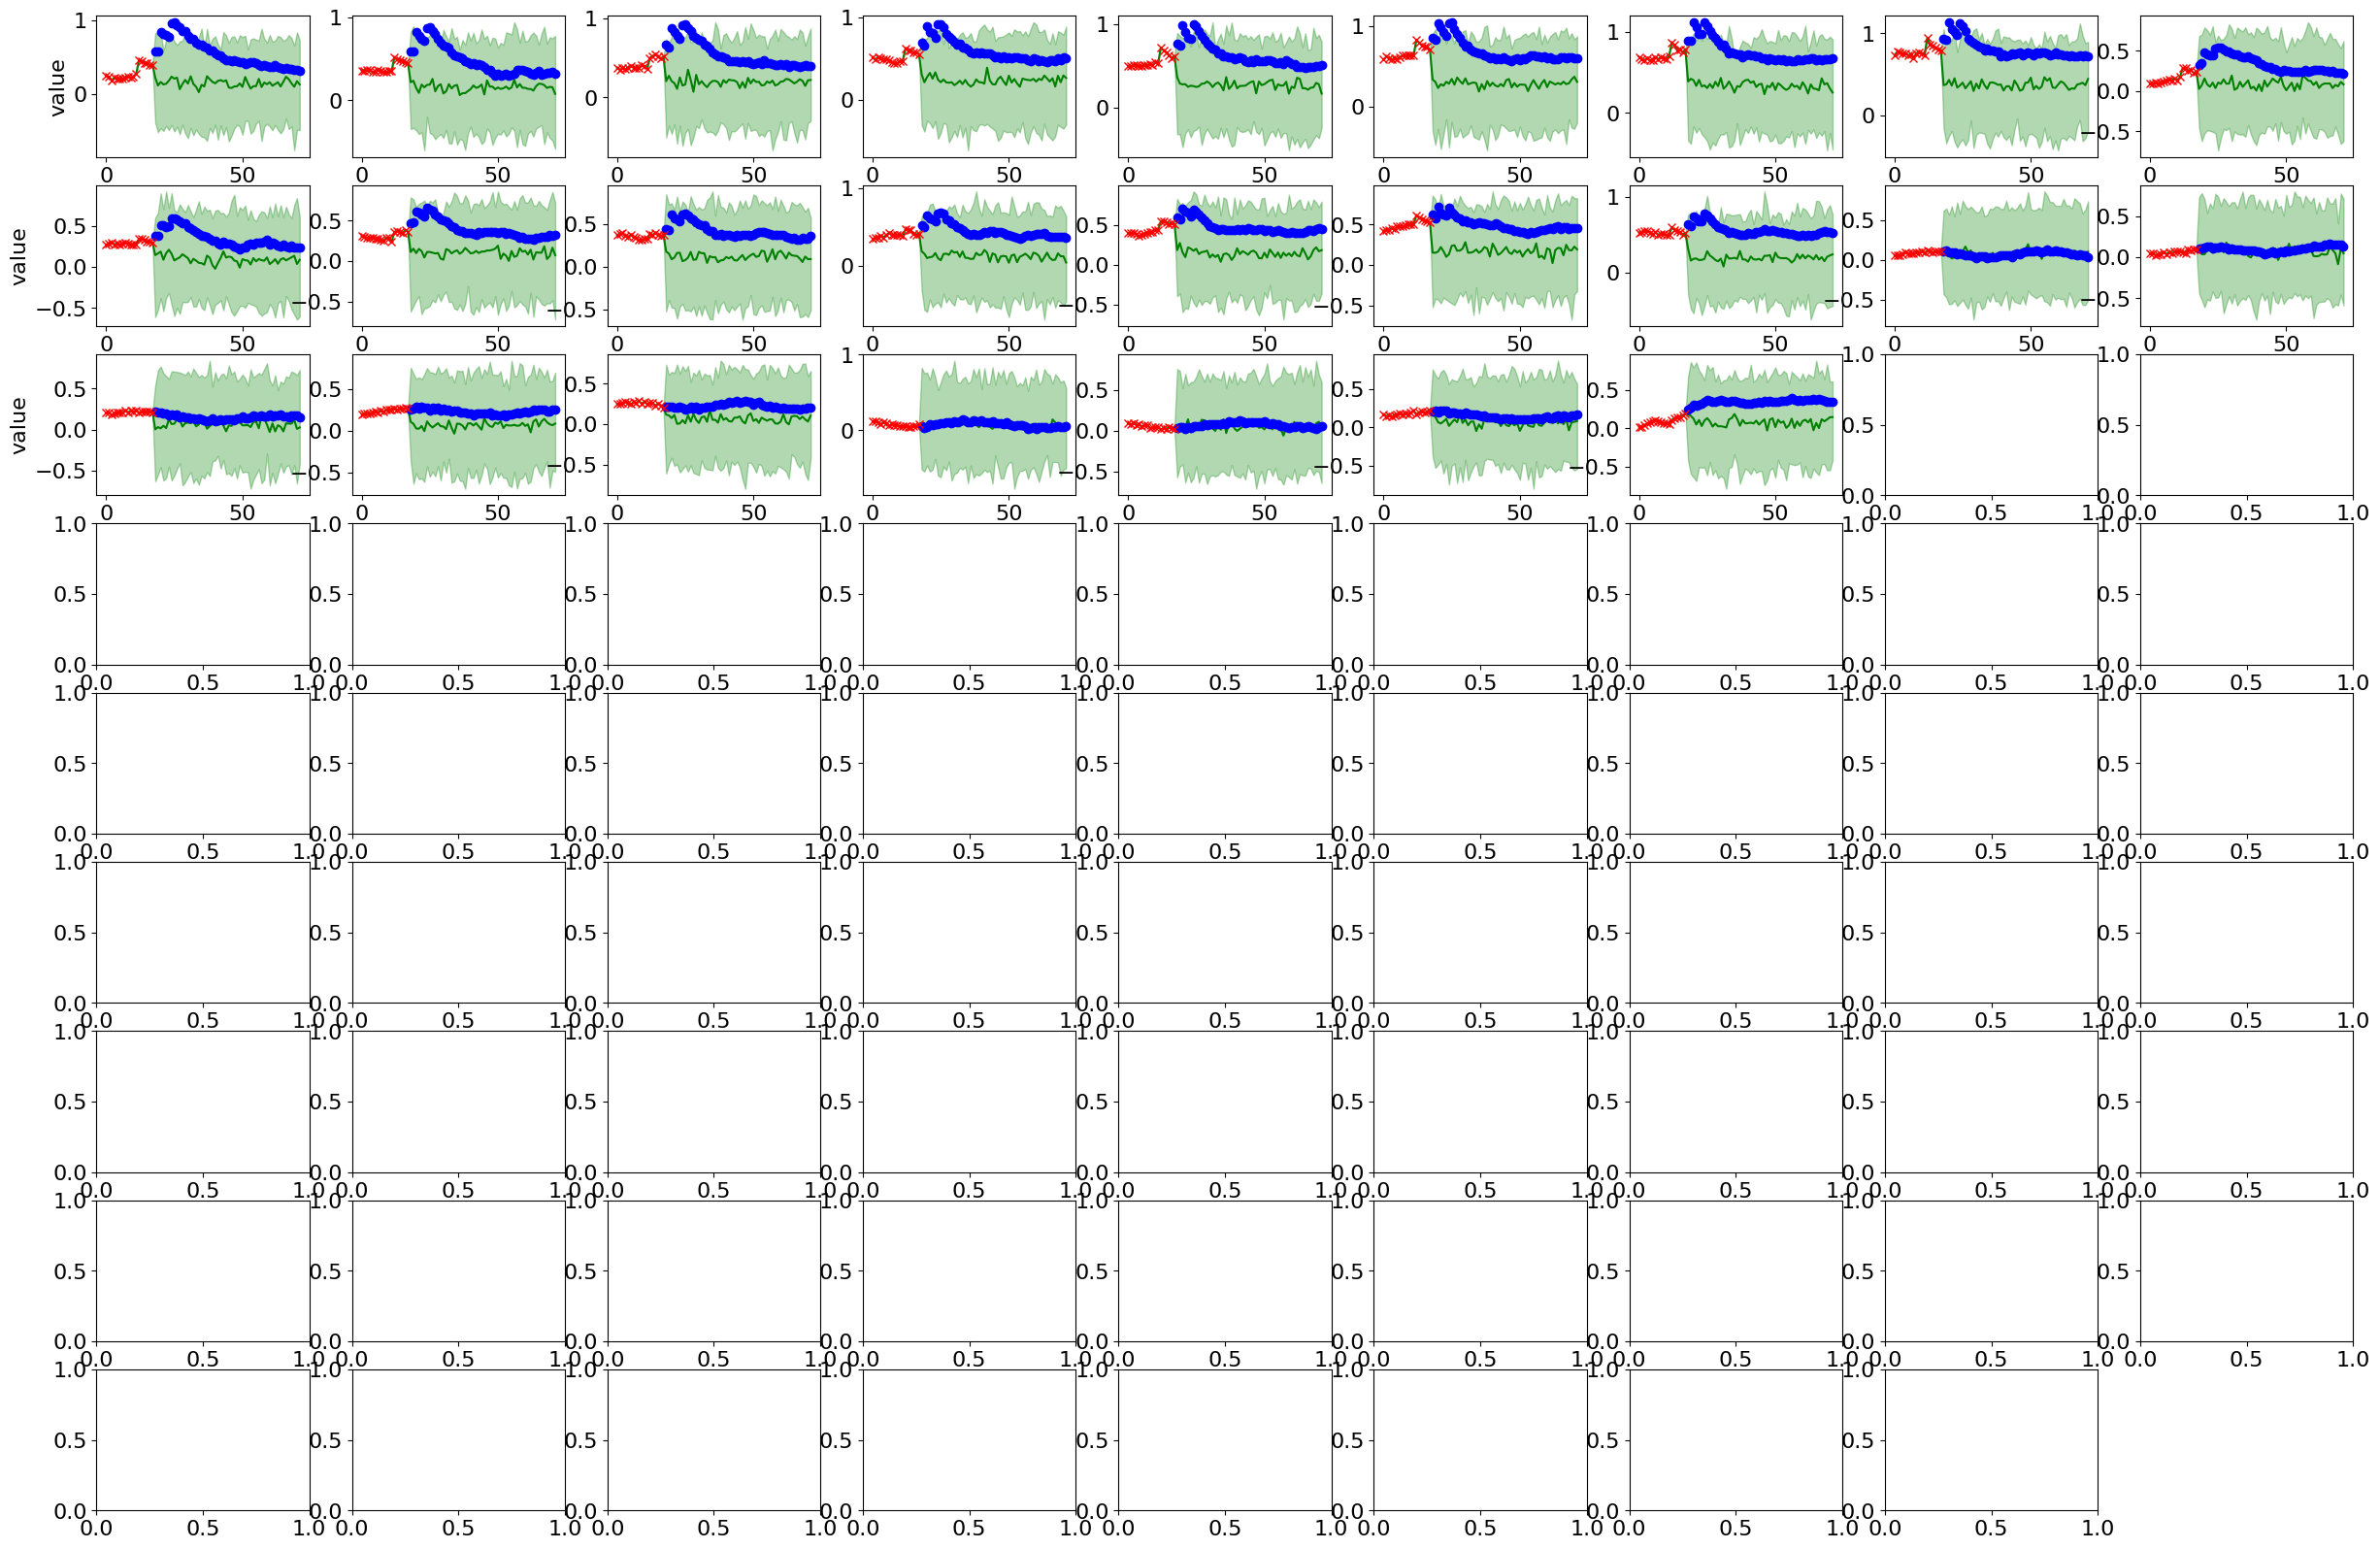

In [19]:
###airquality###
dataind = 4 #change to visualize a different sample

plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(nrows=9, ncols=9,figsize=(30.0, 20.0))
fig.delaxes(axes[-1][-1])

for k in range(K):
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    row = k // 9
    col = k % 9
    axes[row][col].plot(range(0,L), quantiles_imp[2][dataind,:,k], color = 'g',linestyle='solid',label='CSDI')
    axes[row][col].fill_between(range(0,L), quantiles_imp[0][dataind,:,k],quantiles_imp[4][dataind,:,k],
                    color='g', alpha=0.3)
    axes[row][col].plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
    axes[row][col].plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
    if col == 0:
        plt.setp(axes[row, 0], ylabel='value')
    if row == -1:
        plt.setp(axes[-1, col], xlabel='time')


In [20]:
train_loader, valid_loader, test_loader = get_dataloader(device=gpu, batch_size=8, long_data=True)

Loaded SAGD training data with shape:  (100000, 25)
Training dataset len:  4128
Loaded SAGD training data with shape:  (100000, 25)
Valid dataset len:  15
Loaded SAGD training data with shape:  (100000, 25)
Test dataset len:  1


In [21]:
import time

rng = np.random.RandomState(0)

# generate one batch
for batch in test_loader:
    observed_mask = batch['observed_mask']
    # set later half to 0
    #print(observed_mask_forecast.shape)
    real_data = batch['observed_data']

    observed_mask_forecast = observed_mask.clone()
    observed_mask_forecast[:, 90:] = 0

    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_forecast

    observed_mask_forecast = observed_mask_forecast.to(model.device).float()
    observed_data = observed_data.to(model.device).float()
    with torch.no_grad():
        start_time = time.time()  # Start timer
        generated = model.impute(observed_data, observed_mask_forecast, n_samples=100, timestamps=batch['timepoints'])
        end_time = time.time()  # End timer
        break

generated_test = generated.permute([0, 1, 3, 2]).cpu()
X = np.arange(generated_test.shape[0]).reshape(-1, 1)

all_target_np = real_data
all_evalpoint_np = observed_mask.cpu() - observed_mask_forecast.cpu() #observed_mask_forecast.cpu() # with later points se tto 0
all_observed_np = observed_mask.cpu() # all points
all_given_np = observed_mask_forecast.cpu() # observations

K = generated_test.shape[-1] #feature
L = generated_test.shape[-2] #time length

In [22]:
def get_quantile(samples,q,dim=1):
    return torch.quantile(samples,q,axis=dim)

qlist =[0.05,0.25,0.5,0.75,0.95]
quantiles_imp= []
for q in qlist:
    quantiles_imp.append(get_quantile(generated_test, q, dim=1)*(1-all_given_np) + all_target_np * all_given_np)

print(quantiles_imp[0].shape)

torch.Size([1, 552, 25])


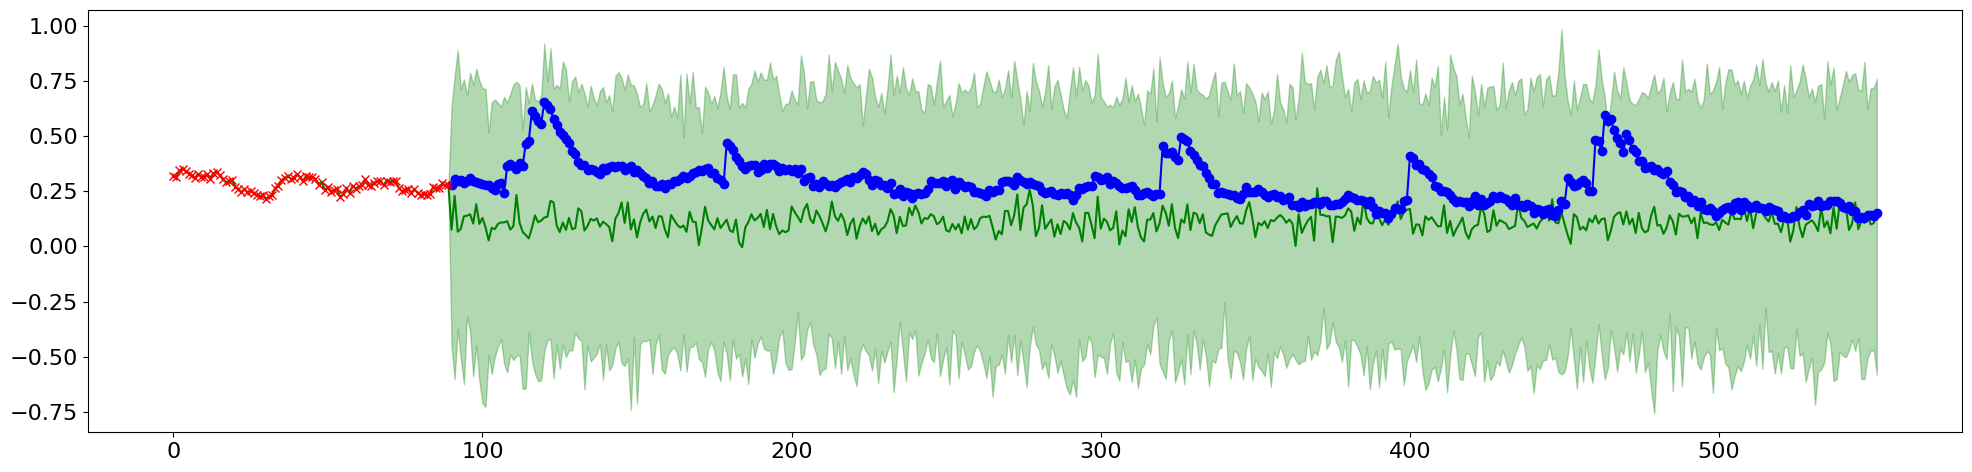

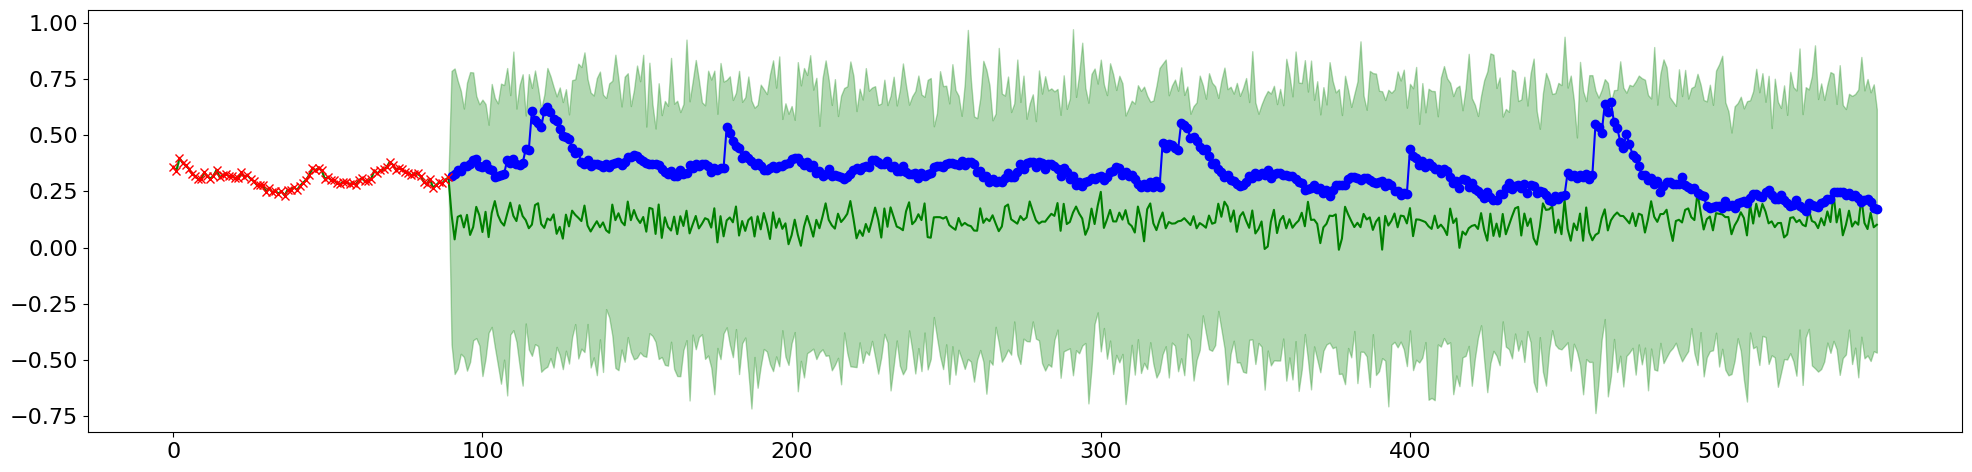

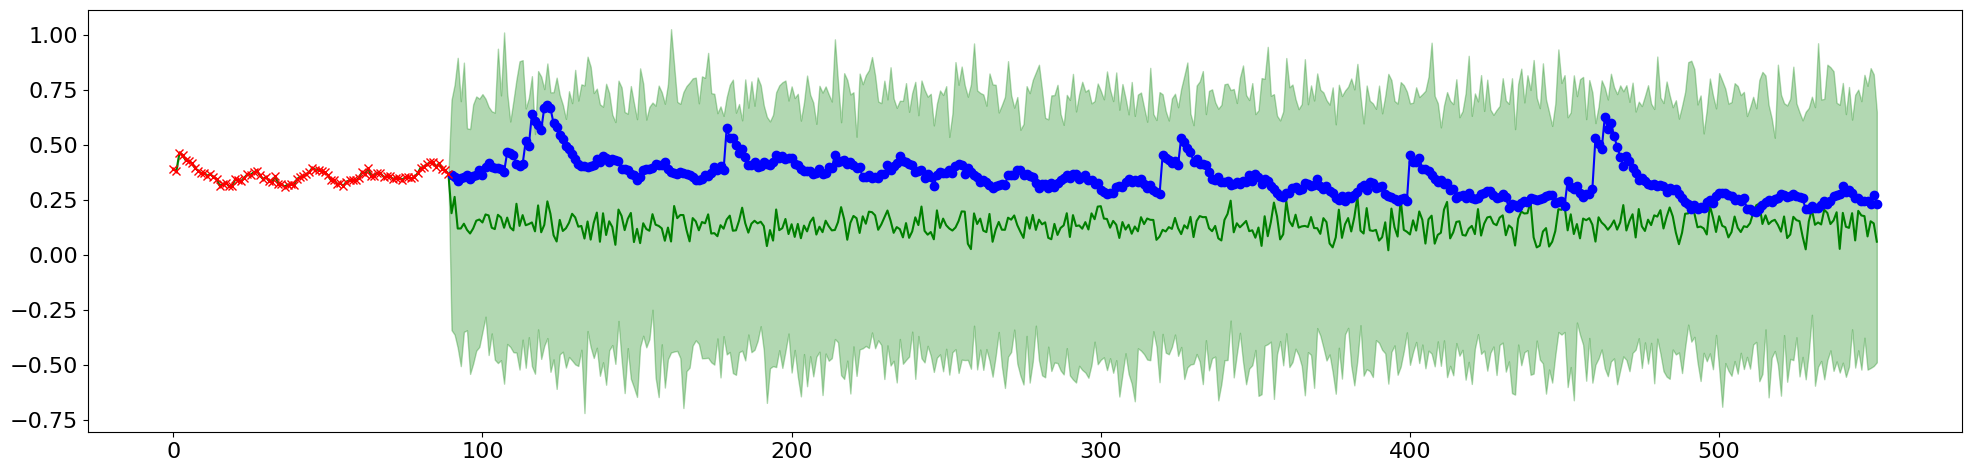

In [23]:
import matplotlib.dates as mdates

###airquality###
dataind = 0 #change to visualize a different sample

plt.rcParams["font.size"] = 16

station = "OPE90012"
indices = list(range(10, 13))
for k in indices:

    fig, ax = plt.subplots(figsize=(20, 5))
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    #row = k // 9
    #col = k % 9
    plt.plot(range(0,L), quantiles_imp[2][dataind,:,k], color = 'g',linestyle='solid',label='CSDI')
    plt.fill_between(range(0,L), quantiles_imp[0][dataind,:,k],quantiles_imp[4][dataind,:,k],
                    color='g', alpha=0.3)
    plt.plot(df.x,df.val, color = 'b',)
    #plt.plot(df2.x,df2.val, color = 'r',)
    plt.plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
    plt.plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
    # replace x axis ticks with dates, only showing days, formatin dates not hours


    plt.tight_layout()
    plt.show()
    plt.show()


In [24]:
seasonal_vars = list(range(12, 24))

real_data.shape, generated_test.shape


#> (torch.Size([1, 552, 25]), torch.Size([1, 100, 552, 25]))

(torch.Size([1, 552, 25]), torch.Size([1, 100, 552, 25]))

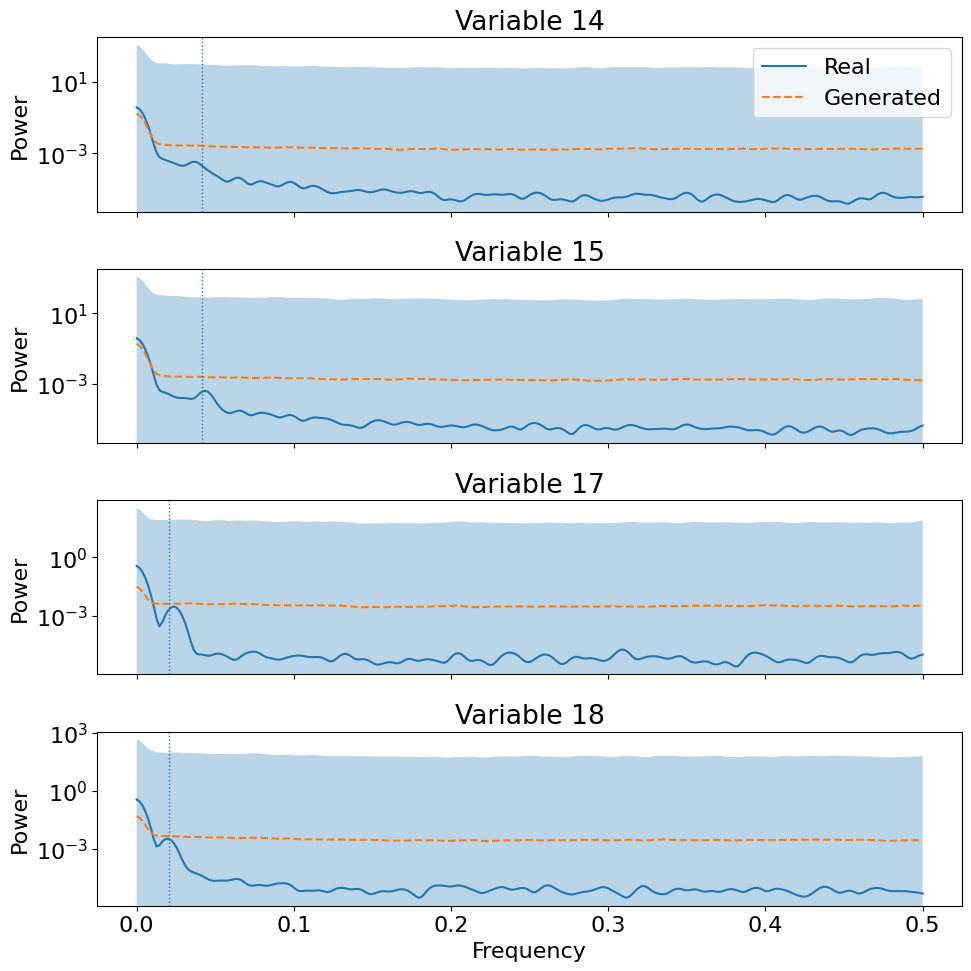

In [25]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

# ----------------------------
# CONFIG
# ----------------------------
seasonal_vars = [14, 15, 17, 18] #list(range(8, 24))
SMOOTH_SIGMA = 2        # set 0 to disable smoothing
NORMALIZE = True        # normalize spectra
LOG_SCALE = True        # log scale for y-axis

# ----------------------------
# DATA PREP
# ----------------------------
# real_data: (1, 552, 25)
# generated_test: (1, 100, 552, 25)

real = real_data[0, :, seasonal_vars]           # (552, 12)
gen  = generated_test[0, :, :, seasonal_vars]  # (100, 552, 12)

T = real.shape[0]

# ----------------------------
# PSD FUNCTION
# ----------------------------
def compute_psd(x, dim):
    fft_vals = torch.fft.rfft(x, dim=dim)
    psd = torch.abs(fft_vals) ** 2
    return psd

# ----------------------------
# COMPUTE PSD
# ----------------------------
real_psd = compute_psd(real, dim=0)     # (freq, vars)
gen_psd  = compute_psd(gen, dim=1)      # (samples, freq, vars)

# Mean + std over simulations
gen_psd_mean = gen_psd.mean(dim=0)
gen_psd_std  = gen_psd.std(dim=0)

# ----------------------------
# NORMALIZATION (optional)
# ----------------------------
if NORMALIZE:
    real_psd = real_psd / real_psd.sum(dim=0, keepdim=True)
    gen_psd_mean = gen_psd_mean / gen_psd_mean.sum(dim=0, keepdim=True)
    gen_psd_std = gen_psd_std / gen_psd_mean.sum(dim=0, keepdim=True)

# ----------------------------
# TO NUMPY
# ----------------------------
real_psd_np = real_psd.cpu().numpy()
gen_psd_mean_np = gen_psd_mean.cpu().numpy()
gen_psd_std_np = gen_psd_std.cpu().numpy()

# ----------------------------
# SMOOTHING (optional)
# ----------------------------
if SMOOTH_SIGMA > 0:
    real_psd_np = scipy.ndimage.gaussian_filter1d(real_psd_np, sigma=SMOOTH_SIGMA, axis=0)
    gen_psd_mean_np = scipy.ndimage.gaussian_filter1d(gen_psd_mean_np, sigma=SMOOTH_SIGMA, axis=0)
    gen_psd_std_np = scipy.ndimage.gaussian_filter1d(gen_psd_std_np, sigma=SMOOTH_SIGMA, axis=0)

# ----------------------------
# FREQUENCY AXIS
# ----------------------------
freqs = np.fft.rfftfreq(T)

# ----------------------------
# PLOTTING
# ----------------------------
n_vars = len(seasonal_vars)
fig, axes = plt.subplots(n_vars, 1, figsize=(10, 2.5 * n_vars), sharex=True)

if n_vars == 1:
    axes = [axes]

for i in range(n_vars):
    ax = axes[i]

    # Real
    ax.plot(freqs, real_psd_np[:, i], label="Real")
    
        
    # Generated mean
    ax.plot(freqs, gen_psd_mean_np[:, i], linestyle="--", label="Generated")

    # Confidence band
    ax.fill_between(
        freqs,
        gen_psd_mean_np[:, i] - gen_psd_std_np[:, i],
        gen_psd_mean_np[:, i] + gen_psd_std_np[:, i],
        alpha=0.3
    )


    ax.set_title(f"Variable {seasonal_vars[i]}")
    ax.set_ylabel("Power")

    if LOG_SCALE:
        ax.set_yscale("log")
    if i == 0:
        ax.legend(loc="upper right")

half = len(axes) // 2  # 6

for i, ax in enumerate(axes):
    if i < half:
        f = 1 / 24
    else:
        f = 1 / 48

    ax.axvline(f, linestyle=":", linewidth=1)

axes[-1].set_xlabel("Frequency")
plt.tight_layout()
plt.show()

In [27]:
import numpy as np
from scipy.stats import wasserstein_distance

EPS = 1e-8  # numerical stability

seasonal_vars = list(range(8, 24))


# Remove DC component (VERY important)
real_psd_np_cut = real_psd_np[1:]
gen_psd_mean_np_cut = gen_psd_mean_np[1:]

n_vars = real_psd_np_cut.shape[1]

lsd_list = []
wass_list = []
rel_err_list = []

for i in range(n_vars):
    r = real_psd_np_cut[:, i]
    g = gen_psd_mean_np_cut[:, i]

    # Normalize to distributions (for Wasserstein)
    r_norm = r / (r.sum() + EPS)
    g_norm = g / (g.sum() + EPS)

    # ------------------
    # 1. Log Spectral Distance
    # ------------------
    lsd = np.sqrt(np.mean((np.log(r + EPS) - np.log(g + EPS))**2))
    lsd_list.append(lsd)

    # ------------------
    # 2. Wasserstein distance
    # ------------------
    wass = wasserstein_distance(
        np.arange(len(r_norm)),
        np.arange(len(g_norm)),
        r_norm,
        g_norm
    )
    wass_list.append(wass)

    # ------------------
    # 3. Relative error
    # ------------------
    rel_err = np.mean(np.abs(r - g) / (r + EPS))
    rel_err_list.append(rel_err)

# ----------------------------
# Aggregate results
# ----------------------------
print("=== Spectral Metrics ===")
print(f"LSD (mean):        {np.mean(lsd_list):.4f}")
print(f"Wasserstein (mean):{np.mean(wass_list):.4f}")
print(f"Rel Error (mean):  {np.mean(rel_err_list):.4f}")

# Per-variable breakdown
print("\nPer-variable LSD:")
for i, val in enumerate(lsd_list):
    print(f"Var {seasonal_vars[i]}: {val:.4f}")

=== Spectral Metrics ===
LSD (mean):        5.7055
Wasserstein (mean):109.0942
Rel Error (mean):  394.8947

Per-variable LSD:
Var 8: 5.3779
Var 9: 5.2007
Var 10: 5.2639
Var 11: 5.5423
Var 12: 5.5650
Var 13: 5.7134
Var 14: 5.6533
Var 15: 5.8360
Var 16: 5.9758
Var 17: 5.9742
Var 18: 5.7103
Var 19: 5.8694
Var 20: 5.7833
Var 21: 5.8709
Var 22: 6.0267
Var 23: 5.9249
